# NYT Connections Puzzle Solver
## DATA 620 Final Project

Authors: Kevin Havis and Aliyah John-Henry

## Introduction

The New York Times hosts several puzzle games on its website, but perhaps the most popular is Connections.

Connetions is a word game where the player is given sixteen words tasked to organize them four at a time into four unknown categories based on implicit patterns.

The primary challenge of the game is that the sixteen words have many possible relations with each other, from semantic meaning, structure of the word, or pop culture references, however the puzzle is looking for four distinct groupings that are mutually exclusive and collectively exhaustive. In practice, players look for logical groups of four words, progressively eliminating words as they get the the groupings correct.

Our goal is to develop a clustering model that is able to correctly group the sixteen words into their four groups.

### Challenge

The difficulty in developing a model to solve this puzzle comes mostly down to the many complex patterns a category could request. A simple cosine similarity is too naive; we must also consider the word structure, including potential suffixes or prefixes. Additionally, the puzzle often intentionally attempts to misdirect the player by providing words that intuitively can be grouped, but do not fit the predetermined category.


### Approach

We have several tools we can use to take on this problem.

#### Data

We have access to historical puzzles and their categories thanks to *Eyefyre* on [GitHub](https://github.com/Eyefyre/NYT-Connections-Answers).


#### Techniques

We must use a combination of techniques to address all potential "angles" of word classification.

- Word Embeddings: Vectorizing the words can give us some initial groupings of similar words by common language 
- Stemming and Lemmitization: Often categories will depend on potential prefixes or suffixes of words, which we can use lemmitization 
- Network analysis: Modeling the words as nodes and their connections as edges is a natural approach to this type of "neighbor" clustering

#### Evaluation

Model evaluation for clustering can be challenging; to measure our model's performance, we will compare against the following benchmarks.

- Random Association: Random grouping of words, measured by accuracy
- Simple Word Vector Embeddings: Singular semantic representation of a word, grouping by most similar
- LLM Performance: Human-equivalent or better performance
- Your authors: Good old human benchmark

In [1]:
# Note - import will take a while as we load all the GloVe embeddings
from project4.data import DataLoader
from project4.embeddings import Embedder

In [2]:
loader = DataLoader()
df = loader.load()

In [ ]:
embedder = Embedder(words=[])

Words: ['club', 'diamond', 'heart', 'spade', 'sandwich', 'knuckle', 'open', 'ham', 'ace', 'king', 'queen', 'jack', 'flush', 'straight', 'full', 'royal']

Loading GloVe embeddings for 16 words...
Embeddings shape: (16, 300)

Computing cosine similarity matrix...
Similarity matrix:
[[ 0.9999999   0.21613273  0.23093626 -0.01247936  0.09775207 -0.02392899
   0.30434898  0.31011045  0.2184578   0.2037913   0.2320672   0.2507844
  -0.00869697  0.2554707   0.2819834   0.31585366]
 [ 0.21613273  1.          0.21192668  0.11824512  0.08566821  0.03675086
   0.14687745  0.07350969  0.15594405  0.19179627  0.23214372  0.20263606
   0.02807982  0.12039275  0.13323589  0.15018058]
 [ 0.23093626  0.21192668  1.         -0.01901736  0.07016852  0.02350879
   0.24221094  0.05314971  0.12194832  0.21747708  0.22896451  0.24929759
   0.10739117  0.1735265   0.20537993  0.1873827 ]
 [-0.01247936  0.11824512 -0.01901736  0.9999999   0.09033093  0.13715658
   0.04290726  0.0856332   0.03617078 -0.00329902

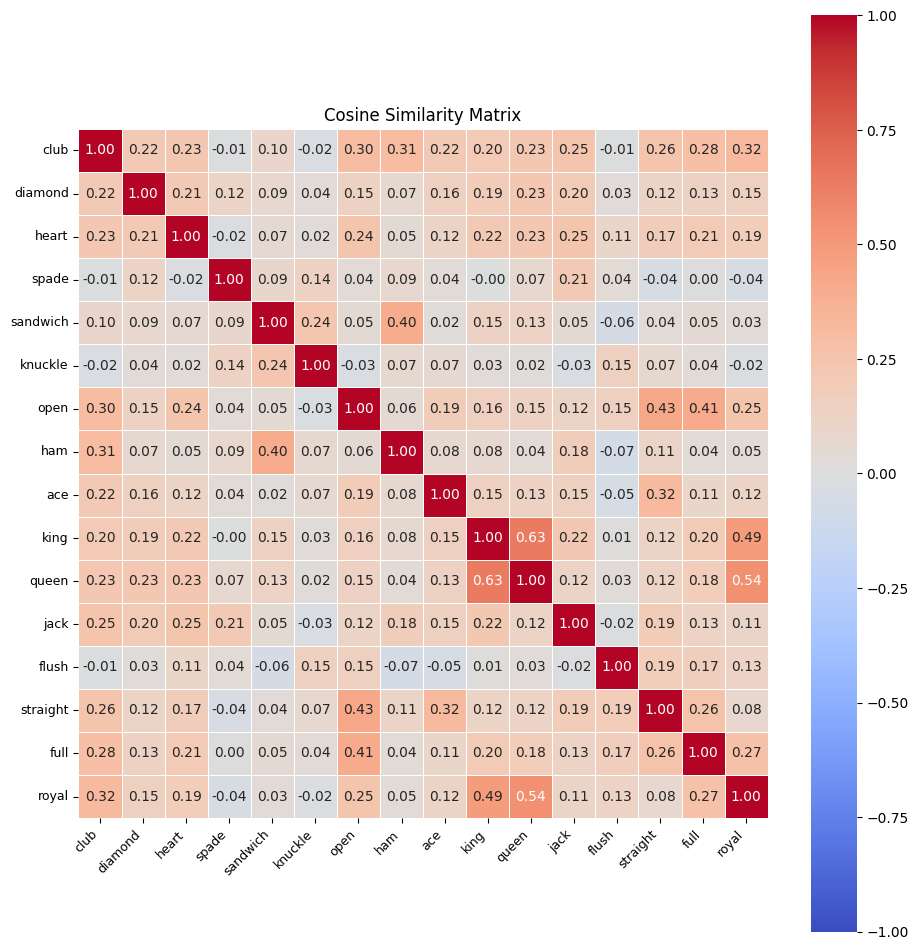

In [6]:
embedder.demo()